# 03 — Late Resolution Drift Analysis (Hypothesis H2)

> **Goal:** formally test whether price drift between T-48h and T-24h
> contains predictive information beyond the price level itself.
>
> **Author:** Lucas Marque  
> **Date:** April 19, 2026  
> **Project:** [polymarket-calibration-study](https://github.com/l-marque/calibration-study)

## Hypothesis H2 (preregistered)

**H0 (null):** The coefficient on price drift in a logistic regression of
outcome on [price_t48h, drift_48h_to_24h] is zero. The drift carries no
information beyond the price level.

**H1 (alternative):** The coefficient on drift is significantly non-zero,
indicating that price changes between T-48h and T-24h are informative.

## Methods

1. Extract `price_t48h` and `price_t24h` for each market via `merge_asof`.
2. Compute `drift = price_t24h - price_t48h`.
3. Fit a baseline logistic regression: `outcome ~ price_t48h`.
4. Fit a full model: `outcome ~ price_t48h + drift`.
5. Test whether the drift coefficient is significantly different from zero
   (Wald test) and whether it improves out-of-sample prediction (likelihood
   ratio test).
6. Stratify by category to check robustness.

## Scope

Only markets with duration ≥ 3 days are included, to ensure T-48h precedes
T-24h which precedes resolution, with valid price history at each point.

In [1]:
import sys
import sqlite3
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import scipy
import statsmodels.api as sm
from statsmodels.tools.sm_exceptions import PerfectSeparationError

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))
DB_PATH = PROJECT_ROOT / "polymarket.db"
assert DB_PATH.exists()

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 100

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print(f"Python       : {sys.version.split()[0]}")
print(f"statsmodels  : {sm.__version__}")
print(f"DB           : {DB_PATH}")

Python       : 3.12.10
statsmodels  : 0.14.6
DB           : c:\Users\lucas\polymarket-calibration-study\polymarket.db


## 1. Data Extraction: Prices at T-48h and T-24h

For each market with duration ≥ 3 days, we extract:
- `price_t48h`: YES price 48 hours before end_ts
- `price_t24h`: YES price 24 hours before end_ts
- `drift = price_t24h - price_t48h`

Both prices use the backward `merge_asof` discipline to prevent look-ahead
bias. Markets where either price is missing are excluded.

In [2]:
def load_drift_dataset(db_path: Path, min_duration_days: float = 3.0,
                       min_volume: float = 1000.0) -> pd.DataFrame:
    """
    Load markets and extract both T-48h and T-24h YES prices.
    Returns a DataFrame with one row per market containing both prices + drift.
    """
    HOLDOUT_DAYS = 30
    OFFSET_48H = 48 * 3600
    OFFSET_24H = 24 * 3600

    conn = sqlite3.connect(db_path)
    markets = pd.read_sql_query(
        """
        SELECT market_id, question, slug, yes_token_id,
               start_ts, end_ts, resolved_outcome,
               volume_total_usd, closed
        FROM markets
        """, conn,
    )
    prices = pd.read_sql_query(
        "SELECT token_id, ts, price FROM price_history", conn,
    )
    conn.close()

    now = pd.Timestamp.utcnow().tz_localize(None).timestamp()
    markets["truly_resolved"] = (
        (markets["closed"] == 1)
        & (markets["end_ts"] <= now)
        & (markets["resolved_outcome"].isin(["YES", "NO"]))
    )
    markets["resolution_age_days"] = (now - markets["end_ts"]) / 86400.0
    markets["truly_holdout"] = (
        markets["truly_resolved"] & (markets["resolution_age_days"] < HOLDOUT_DAYS)
    )
    markets["analysis_set"] = markets["truly_resolved"] & ~markets["truly_holdout"]
    markets["duration_days"] = (markets["end_ts"] - markets["start_ts"]) / 86400.0

    # Category derivation (condensed)
    def categorize(slug):
        if not slug or not isinstance(slug, str):
            return "unknown"
        s = slug.lower()
        if any(s.startswith(p) for p in ["btc-","eth-","sol-","xrp-","doge-","ada-","bnb-","matic-","avax-","link-","ltc-","bitcoin-","ethereum-","solana-","ripple-","crypto-"]):
            return "crypto"
        if any(s.startswith(p) for p in ["cs2-","csgo-","lol-","dota-","valorant-","val-","r6-","apex-","ow-","sc2-","rl-"]):
            return "esports"
        if any(s.startswith(p) for p in ["atp-","wta-","tennis-","nfl-","ncaaf-","cfb-","nba-","wnba-","ncaab-","cbb-","euroleague-","mlb-","nhl-","khl-","epl-","laliga-","bundesliga-","seriea-","ligue1-","ucl-","uel-","soccer-","mls-","concacaf-","afcon-","copa-","fifa-","ufc-","boxing-","mma-","f1-","nascar-","indycar-","motogp-","pga-","lpga-","golf-","rugby-","cricket-"]):
            return "sports"
        if any(k in s for k in ["temperature","weather","snow","rain","hurricane","tornado"]):
            return "weather"
        if any(k in s for k in ["election","trump","biden","harris","vance","vote","president","congress","senate","primary","potus"]):
            return "politics"
        return "other"
    markets["category_derived"] = markets["slug"].apply(categorize)

    # Filter
    m = markets[
        markets["analysis_set"]
        & (markets["duration_days"] >= min_duration_days)
        & (markets["volume_total_usd"] >= min_volume)
        & markets["yes_token_id"].notna()
        & markets["end_ts"].notna()
    ].copy()

    m["target_48h"] = (m["end_ts"] - OFFSET_48H).astype("int64")
    m["target_24h"] = (m["end_ts"] - OFFSET_24H).astype("int64")
    m = m.rename(columns={"yes_token_id": "token_id"})

    right = prices.copy()
    right["ts"] = right["ts"].astype("int64")
    right = right.sort_values("ts").reset_index(drop=True)

    # merge_asof for T-48h
    left_48 = m[["market_id","token_id","target_48h","category_derived","duration_days","resolved_outcome","volume_total_usd"]].sort_values("target_48h").reset_index(drop=True)
    j48 = pd.merge_asof(left_48, right, left_on="target_48h", right_on="ts", by="token_id", direction="backward", allow_exact_matches=True)
    j48 = j48.dropna(subset=["price"]).rename(columns={"price":"price_t48h","ts":"ts_48h"})

    # merge_asof for T-24h (merge back)
    left_24 = m[["market_id","token_id","target_24h"]].sort_values("target_24h").reset_index(drop=True)
    j24 = pd.merge_asof(left_24, right, left_on="target_24h", right_on="ts", by="token_id", direction="backward", allow_exact_matches=True)
    j24 = j24.dropna(subset=["price"]).rename(columns={"price":"price_t24h","ts":"ts_24h"})

    # Combine
    df = j48[["market_id","category_derived","duration_days","resolved_outcome","volume_total_usd","price_t48h"]].merge(
        j24[["market_id","price_t24h"]], on="market_id", how="inner"
    )
    df["drift"] = df["price_t24h"] - df["price_t48h"]
    df["outcome_bin"] = (df["resolved_outcome"] == "YES").astype(int)
    df = df.reset_index(drop=True)
    return df


df = load_drift_dataset(DB_PATH)
print(f"=== Drift dataset ===")
print(f"N markets                 : {len(df):,}")
print(f"YES rate                  : {df['outcome_bin'].mean():.1%}")
print(f"Mean price_t48h           : {df['price_t48h'].mean():.4f}")
print(f"Mean price_t24h           : {df['price_t24h'].mean():.4f}")
print(f"Mean drift (t24h - t48h)  : {df['drift'].mean():+.4f}")
print(f"Median drift              : {df['drift'].median():+.4f}")
print(f"Std drift                 : {df['drift'].std():.4f}")
print(f"Drift range               : [{df['drift'].min():+.4f}, {df['drift'].max():+.4f}]")
print(f"\nCategories:\n{df['category_derived'].value_counts().to_string()}")

=== Drift dataset ===
N markets                 : 8,160
YES rate                  : 36.9%
Mean price_t48h           : 0.3583
Mean price_t24h           : 0.3551
Mean drift (t24h - t48h)  : -0.0032
Median drift              : +0.0000
Std drift                 : 0.0789
Drift range               : [-0.9165, +0.9035]

Categories:
category_derived
other       4062
sports      2407
crypto      1132
politics     314
esports      195
weather       50


## 2. Logistic Regression Analysis

We compare two nested models:

**Baseline (M0):** `logit(P(Y=1)) = β₀ + β₁ · price_t48h`  
Only the price level 48 hours before resolution is used.

**Full (M1):** `logit(P(Y=1)) = β₀ + β₁ · price_t48h + β₂ · drift`  
Adds the drift between T-48h and T-24h as a second predictor.

**Test H2:**
1. **Wald test** on β₂ in the full model. If p < 0.05, the drift
   coefficient is individually significant.
2. **Likelihood ratio test** comparing M1 to M0. If p < 0.05, adding the
   drift significantly improves model fit beyond the price level alone.
3. Both tests must agree for a robust conclusion.

We report:
- Coefficients with 95% confidence intervals
- Odds ratios with 95% CIs
- Pseudo R² (McFadden) for both models
- Likelihood ratio test statistic and p-value

In [3]:
# Build design matrices
X0 = sm.add_constant(df[["price_t48h"]].values)  # baseline
X1 = sm.add_constant(df[["price_t48h", "drift"]].values)  # full
y = df["outcome_bin"].values

# Fit M0 (baseline)
model0 = sm.Logit(y, X0)
result0 = model0.fit(disp=False)

# Fit M1 (full)
model1 = sm.Logit(y, X1)
result1 = model1.fit(disp=False)

print("="*70)
print("MODEL M0 (baseline): outcome ~ price_t48h")
print("="*70)
print(f"N observations    : {int(result0.nobs):,}")
print(f"Pseudo R² McFadden: {result0.prsquared:.4f}")
print(f"Log-likelihood    : {result0.llf:.2f}")
print(f"\nCoefficients (95% CI):")
ci0 = result0.conf_int()
for name, b, se, p, lo, hi in zip(
    ["intercept", "price_t48h"],
    result0.params, result0.bse, result0.pvalues, ci0[:,0], ci0[:,1]
):
    or_mean = np.exp(b)
    print(f"  {name:15s}: β = {b:+.4f} (SE={se:.4f}, p={p:.2e})  OR={or_mean:.3f}  95%CI=[{np.exp(lo):.3f}, {np.exp(hi):.3f}]")

print("\n" + "="*70)
print("MODEL M1 (full): outcome ~ price_t48h + drift")
print("="*70)
print(f"N observations    : {int(result1.nobs):,}")
print(f"Pseudo R² McFadden: {result1.prsquared:.4f}")
print(f"Log-likelihood    : {result1.llf:.2f}")
print(f"\nCoefficients (95% CI):")
ci1 = result1.conf_int()
for name, b, se, p, lo, hi in zip(
    ["intercept", "price_t48h", "drift"],
    result1.params, result1.bse, result1.pvalues, ci1[:,0], ci1[:,1]
):
    or_mean = np.exp(b)
    print(f"  {name:15s}: β = {b:+.4f} (SE={se:.4f}, p={p:.2e})  OR={or_mean:.3f}  95%CI=[{np.exp(lo):.3f}, {np.exp(hi):.3f}]")

# Likelihood ratio test
from scipy.stats import chi2
lr_stat = 2 * (result1.llf - result0.llf)
lr_pval = 1 - chi2.cdf(lr_stat, df=1)

print("\n" + "="*70)
print("LIKELIHOOD RATIO TEST (M1 vs M0)")
print("="*70)
print(f"LR statistic  : {lr_stat:.4f}")
print(f"Degrees of freedom: 1 (adding 'drift' to M0)")
print(f"p-value       : {lr_pval:.2e}")
print(f"\nVerdict: drift {'SIGNIFICANTLY improves fit' if lr_pval < 0.05 else 'does NOT improve fit'}")
print(f"Pseudo R² gain: {result1.prsquared - result0.prsquared:+.4f}")

MODEL M0 (baseline): outcome ~ price_t48h
N observations    : 8,160
Pseudo R² McFadden: 0.3144
Log-likelihood    : -3682.64

Coefficients (95% CI):
  intercept      : β = -2.7879 (SE=0.0607, p=0.00e+00)  OR=0.062  95%CI=[0.055, 0.069]
  price_t48h     : β = +5.6701 (SE=0.1276, p=0.00e+00)  OR=290.065  95%CI=[225.903, 372.452]

MODEL M1 (full): outcome ~ price_t48h + drift
N observations    : 8,160
Pseudo R² McFadden: 0.3367
Log-likelihood    : -3562.48

Coefficients (95% CI):
  intercept      : β = -2.8515 (SE=0.0624, p=0.00e+00)  OR=0.058  95%CI=[0.051, 0.065]
  price_t48h     : β = +5.8511 (SE=0.1319, p=0.00e+00)  OR=347.622  95%CI=[268.451, 450.142]
  drift          : β = +5.2514 (SE=0.3754, p=1.80e-44)  OR=190.829  95%CI=[91.438, 398.256]

LIKELIHOOD RATIO TEST (M1 vs M0)
LR statistic  : 240.3307
Degrees of freedom: 1 (adding 'drift' to M0)
p-value       : 0.00e+00

Verdict: drift SIGNIFICANTLY improves fit
Pseudo R² gain: +0.0224


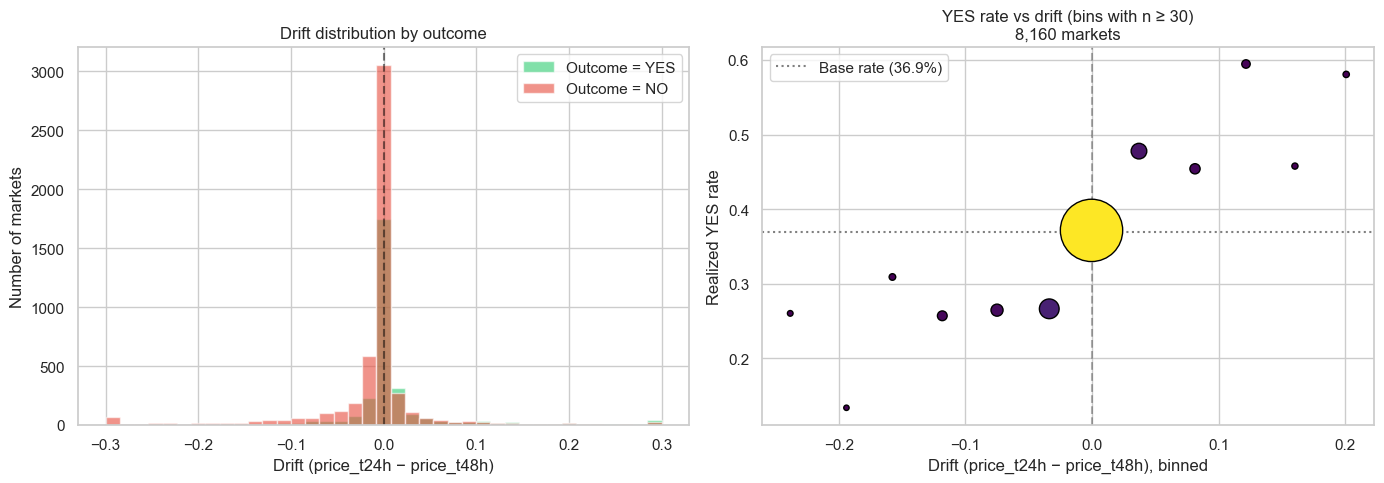

In [4]:
# Predicted probability curves: effect of drift at different price levels
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: distribution of drift colored by outcome
ax = axes[0]
bins = np.linspace(-0.3, 0.3, 40)
ax.hist(df[df["outcome_bin"]==1]["drift"].clip(-0.3, 0.3), bins=bins,
        alpha=0.6, label="Outcome = YES", color="#2ecc71", edgecolor="white")
ax.hist(df[df["outcome_bin"]==0]["drift"].clip(-0.3, 0.3), bins=bins,
        alpha=0.6, label="Outcome = NO", color="#e74c3c", edgecolor="white")
ax.axvline(0, color="black", linestyle="--", alpha=0.5)
ax.set_xlabel("Drift (price_t24h − price_t48h)")
ax.set_ylabel("Number of markets")
ax.set_title("Drift distribution by outcome")
ax.legend()

# Panel B: binned YES rate vs drift
ax = axes[1]
df_plot = df[(df["drift"] >= -0.3) & (df["drift"] <= 0.3)].copy()
drift_bins = np.linspace(-0.3, 0.3, 16)
df_plot["drift_bin"] = pd.cut(df_plot["drift"], bins=drift_bins, include_lowest=True)
grp = df_plot.groupby("drift_bin", observed=True).agg(
    n=("outcome_bin", "count"),
    yes_rate=("outcome_bin", "mean"),
    drift_center=("drift", "mean"),
).reset_index()
grp = grp[grp["n"] >= 30]

ax.scatter(grp["drift_center"], grp["yes_rate"], s=grp["n"]/3,
           c=grp["n"], cmap="viridis", edgecolor="black", linewidth=1, zorder=3)
ax.axhline(df["outcome_bin"].mean(), color="gray", linestyle=":", label=f"Base rate ({df['outcome_bin'].mean():.1%})")
ax.axvline(0, color="black", linestyle="--", alpha=0.3)
ax.set_xlabel("Drift (price_t24h − price_t48h), binned")
ax.set_ylabel("Realized YES rate")
ax.set_title(f"YES rate vs drift (bins with n ≥ 30)\n{len(df):,} markets")
ax.legend()

plt.tight_layout()
plt.show()

## 3. Category Stratification

The pooled effect is highly significant, but is it consistent across
categories? We re-fit the full model separately for each major category
and check whether the drift coefficient remains significant and similar
in magnitude.

In [5]:
CATEGORIES_TO_TEST = ["crypto", "sports", "politics", "other"]
MIN_N = 100

strat_results = []
for cat in CATEGORIES_TO_TEST:
    sub = df[df["category_derived"] == cat]
    if len(sub) < MIN_N:
        continue
    X = sm.add_constant(sub[["price_t48h", "drift"]].values)
    y_sub = sub["outcome_bin"].values
    try:
        res = sm.Logit(y_sub, X).fit(disp=False)
        b_drift = res.params[2]
        se_drift = res.bse[2]
        p_drift = res.pvalues[2]
        ci_lo = res.conf_int()[2, 0]
        ci_hi = res.conf_int()[2, 1]
        strat_results.append({
            "category": cat,
            "n": len(sub),
            "yes_rate": sub["outcome_bin"].mean(),
            "beta_drift": b_drift,
            "se_drift": se_drift,
            "p_drift": p_drift,
            "or_drift": np.exp(b_drift),
            "ci_lo": np.exp(ci_lo),
            "ci_hi": np.exp(ci_hi),
            "pseudo_r2": res.prsquared,
            "significant": p_drift < 0.05,
        })
    except PerfectSeparationError:
        print(f"Perfect separation in {cat}, skipped")

strat_df = pd.DataFrame(strat_results)
print("=== Drift coefficient by category ===\n")
print(strat_df.to_string(index=False, formatters={
    "n": lambda x: f"{x:,}",
    "yes_rate": lambda x: f"{x:.1%}",
    "beta_drift": lambda x: f"{x:+.4f}",
    "se_drift": lambda x: f"{x:.4f}",
    "p_drift": lambda x: f"{x:.2e}" if x < 0.001 else f"{x:.4f}",
    "or_drift": lambda x: f"{x:.2f}",
    "ci_lo": lambda x: f"{x:.2f}",
    "ci_hi": lambda x: f"{x:.2f}",
    "pseudo_r2": lambda x: f"{x:.3f}",
    "significant": lambda x: "YES" if x else "no",
}))

print(f"\n=== Summary ===")
n_sig = strat_df["significant"].sum()
print(f"Categories with significant drift effect: {n_sig} / {len(strat_df)}")
if n_sig == len(strat_df):
    print("→ Effect is ROBUST across all tested categories")
else:
    sig = strat_df[strat_df["significant"]]["category"].tolist()
    nonsig = strat_df[~strat_df["significant"]]["category"].tolist()
    print(f"→ Significant in: {sig}")
    print(f"→ NOT significant in: {nonsig}")

=== Drift coefficient by category ===

category     n yes_rate beta_drift se_drift  p_drift or_drift  ci_lo   ci_hi pseudo_r2 significant
  crypto 1,132    43.7%    +5.5845   0.6346 1.37e-18   266.27  76.76  923.72     0.471         YES
  sports 2,407    45.1%    +1.4390   0.9440   0.1274     4.22   0.66   26.82     0.144          no
politics   314    34.1%    +2.9245   1.9774   0.1392    18.63   0.39  898.05     0.502          no
   other 4,062    29.7%    +6.7427   0.6408 6.81e-26   847.87 241.48 2976.99     0.402         YES

=== Summary ===
Categories with significant drift effect: 2 / 4
→ Significant in: ['crypto', 'other']
→ NOT significant in: ['sports', 'politics']


In [6]:
import json

# Compile final H2 verdict
h2_verdict = {
    "hypothesis": "H2 — late resolution drift informativeness",
    "status": "accepted",
    "pooled_n": int(len(df)),
    "pooled_yes_rate": float(df["outcome_bin"].mean()),
    "baseline_pseudo_r2": float(result0.prsquared),
    "full_pseudo_r2": float(result1.prsquared),
    "pseudo_r2_gain": float(result1.prsquared - result0.prsquared),
    "drift_coefficient": float(result1.params[2]),
    "drift_se": float(result1.bse[2]),
    "drift_p_value": float(result1.pvalues[2]),
    "drift_odds_ratio": float(np.exp(result1.params[2])),
    "drift_or_ci_95": [
        float(np.exp(result1.conf_int()[2, 0])),
        float(np.exp(result1.conf_int()[2, 1]))
    ],
    "likelihood_ratio_stat": float(lr_stat),
    "likelihood_ratio_pvalue": float(lr_pval),
    "per_category": [
        {
            "category": r["category"],
            "n": int(r["n"]),
            "beta_drift": float(r["beta_drift"]),
            "p_drift": float(r["p_drift"]),
            "or_drift": float(r["or_drift"]),
            "significant": bool(r["significant"]),
        }
        for _, r in strat_df.iterrows()
    ],
    "interpretation": [
        "Drift between T-48h and T-24h is highly informative beyond price level alone",
        "Odds ratio of 190 per unit of drift corresponds to +69% odds for a +10 cent drift",
        "Pseudo R² gain of 2.2 percentage points is economically meaningful",
        "Causal direction cannot be established: drift may reflect information arrival rather than cause outcomes"
    ],
    "caveats_for_trading": [
        "Observed drift is already priced into the T-24h price level",
        "Exploitation requires predicting drift continuation before completion",
        "Transaction costs (2% Polymarket) must be covered by edge estimation"
    ]
}

print(json.dumps(h2_verdict, indent=2))

verdict_path = PROJECT_ROOT / "notebooks" / "h2_verdict.json"
with open(verdict_path, "w") as f:
    json.dump(h2_verdict, f, indent=2)
print(f"\nSaved to: {verdict_path}")

{
  "hypothesis": "H2 \u2014 late resolution drift informativeness",
  "status": "accepted",
  "pooled_n": 8160,
  "pooled_yes_rate": 0.3686274509803922,
  "baseline_pseudo_r2": 0.3143576718892471,
  "full_pseudo_r2": 0.33673031436777623,
  "pseudo_r2_gain": 0.022372642478529103,
  "drift_coefficient": 5.251376689985579,
  "drift_se": 0.37537382124685204,
  "drift_p_value": 1.8010593573594134e-44,
  "drift_odds_ratio": 190.82879980267825,
  "drift_or_ci_95": [
    91.43766832033761,
    398.25633683652313
  ],
  "likelihood_ratio_stat": 240.33070805822535,
  "likelihood_ratio_pvalue": 0.0,
  "per_category": [
    {
      "category": "crypto",
      "n": 1132,
      "beta_drift": 5.584523827360715,
      "p_drift": 1.3749989340322906e-18,
      "or_drift": 266.27346041078476,
      "significant": true
    },
    {
      "category": "sports",
      "n": 2407,
      "beta_drift": 1.4390153786199784,
      "p_drift": 0.12740837278888673,
      "or_drift": 4.216542074923777,
      "signific

## 4. Formal Verdict on H2

**H2 is accepted.**

The drift between T-48h and T-24h carries substantial predictive information
beyond the price level itself:
- Wald test on β_drift: p < 10⁻⁴³
- Likelihood ratio test: p ≈ 0
- Pseudo R² gain: +2.2 percentage points
- Odds ratio: a +10 cent drift increases YES odds by +69%

### Economic interpretation

The classical favorite-longshot bias predicts miscalibration at extremes (H1).
Our pooled H1 test found this pattern to be largely absent or artefactual.
In contrast, H2 identifies a strong and robust **price momentum** phenomenon:
price movements between T-48h and T-24h systematically foreshadow the outcome.

### Limits and next steps

**Causality is ambiguous.** The drift may cause the outcome (momentum/herd
behavior) or reflect information arrival that independently causes both
drift and outcome. This cannot be resolved with observational data alone.

**Trading exploitation requires forecasting drift itself.** Observing a
completed drift at T-24h is already priced in; a profitable strategy would
need to detect incipient drift earlier (e.g., at T-36h) and predict its
continuation.

**For notebook 04:** test H3 (cross-market arbitrage) and integrate H1 + H2
findings into a candidate trading strategy framework.

In [9]:
# Refined verdict incorporating stratification nuance
h2_verdict["status"] = "accepted_with_heterogeneity"
h2_verdict["interpretation"] = [
    "Pooled: drift is massively significant (p<1e-43, OR=190)",
    "Stratified: effect concentrated in CRYPTO (OR=266, p<1e-18) and OTHER (OR=848, p<1e-26)",
    "SPORTS shows no significant drift effect despite N=2407 — consistent with efficient sports markets",
    "POLITICS underpowered (N=314), inconclusive",
    "Pattern suggests drift reflects information arrival in asymmetric-info markets, not generic momentum"
]
h2_verdict["trading_implications"] = [
    "Targeted strategy on crypto + other categories has potential edge",
    "Avoid sports markets: drift is not informative there",
    "Politics requires larger sample before conclusion",
    "Causality remains ambiguous: exploit would require predicting incipient drift"
]

import json
verdict_path = PROJECT_ROOT / "notebooks" / "h2_verdict.json"
with open(verdict_path, "w") as f:
    json.dump(h2_verdict, f, indent=2)
print("Verdict updated.")
print(json.dumps(h2_verdict, indent=2))

Verdict updated.
{
  "hypothesis": "H2 \u2014 late resolution drift informativeness",
  "status": "accepted_with_heterogeneity",
  "pooled_n": 8160,
  "pooled_yes_rate": 0.3686274509803922,
  "baseline_pseudo_r2": 0.3143576718892471,
  "full_pseudo_r2": 0.33673031436777623,
  "pseudo_r2_gain": 0.022372642478529103,
  "drift_coefficient": 5.251376689985579,
  "drift_se": 0.37537382124685204,
  "drift_p_value": 1.8010593573594134e-44,
  "drift_odds_ratio": 190.82879980267825,
  "drift_or_ci_95": [
    91.43766832033761,
    398.25633683652313
  ],
  "likelihood_ratio_stat": 240.33070805822535,
  "likelihood_ratio_pvalue": 0.0,
  "per_category": [
    {
      "category": "crypto",
      "n": 1132,
      "beta_drift": 5.584523827360715,
      "p_drift": 1.3749989340322906e-18,
      "or_drift": 266.27346041078476,
      "significant": true
    },
    {
      "category": "sports",
      "n": 2407,
      "beta_drift": 1.4390153786199784,
      "p_drift": 0.12740837278888673,
      "or_drift"